In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
input = pd.read_csv(r'./Dataset/extracted_dataset/non-multisegment/non-multisegment_input.csv')
src = pd.read_csv(r'./Dataset/extracted_dataset/non-multisegment/non-multisegment_output.csv')

In [3]:
input.head()

,filename,Event,EventTAG,LAT,LON,DEP,LEN_f,WID,Mw,Mo,...,HR-GPS-Data,Hr-GPS-Data,InSAR-Data,Other-Data,SAT-Data,SPOT-Data,hr-GPS-Data,inSAR-Data,level-Data,tril-Data
0,s1906SANFRA01SONG.fsp,San Francisco (Calif.),s1906SANFRA01SONG,37.78,-122.51,10.0,480.0,12.0,7.91,8.150000e+20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,s1906SANFRA01THAT.fsp,San Francisco (Calif.),s1906SANFRA01THAT,37.78,-122.51,10.0,480.0,10.0,7.91,8.120000e+20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,s1923KANTOJ01KOBA.fsp,Kanto (Japan),s1923KANTOJ01KOBA,35.40,139.20,14.6,130.0,70.0,8.08,1.460000e+21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,s1923KANTOJ01WALD.fsp,Kanto (Japan),s1923KANTOJ01WALD,35.40,139.20,14.6,130.0,70.0,7.95,9.330000e+20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,s1944TONANK01ICHI.fsp,Tonankai (Japan),s1944TONANK01ICHI,33.77,135.96,30.0,220.0,140.0,8.04,1.310000e+21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Total unique shapes: 271
Most common shape: 3x3 (Count: 24)
Shape with most cells: 3663x5297 (Total: 19402911 cells)
Average grid size: 620181.2 cells


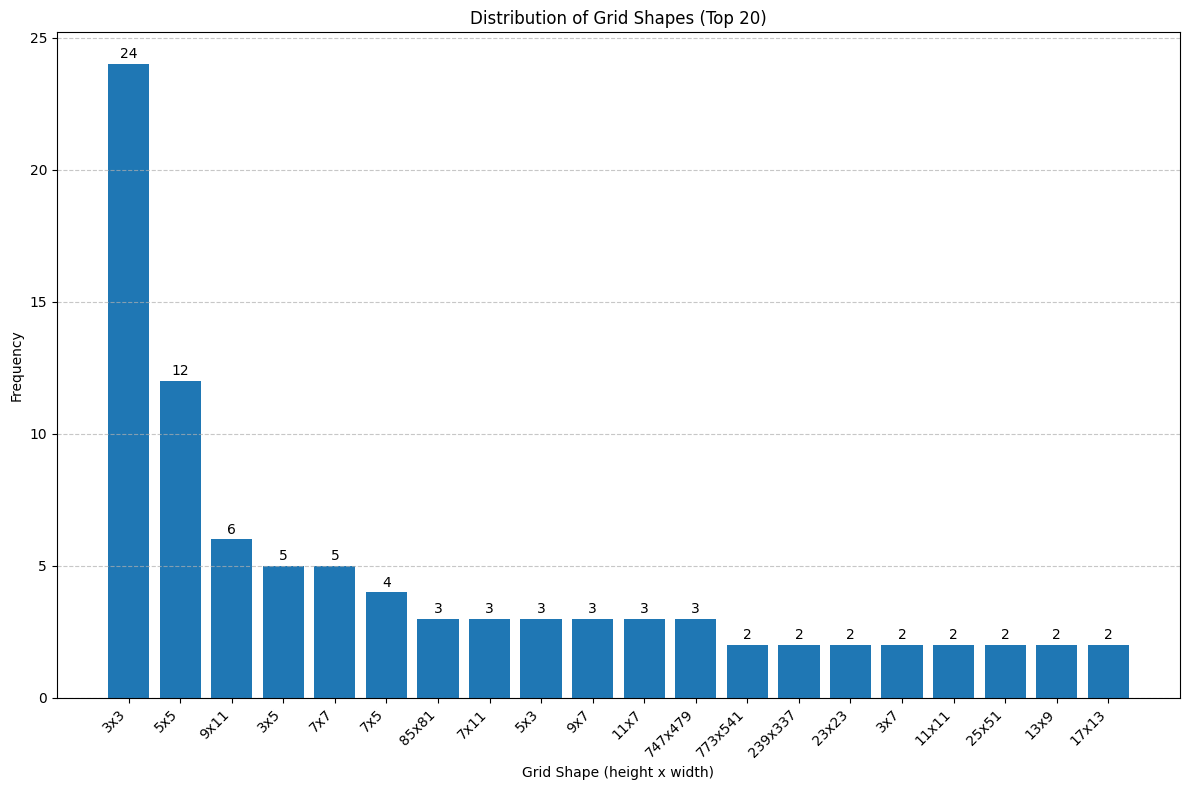

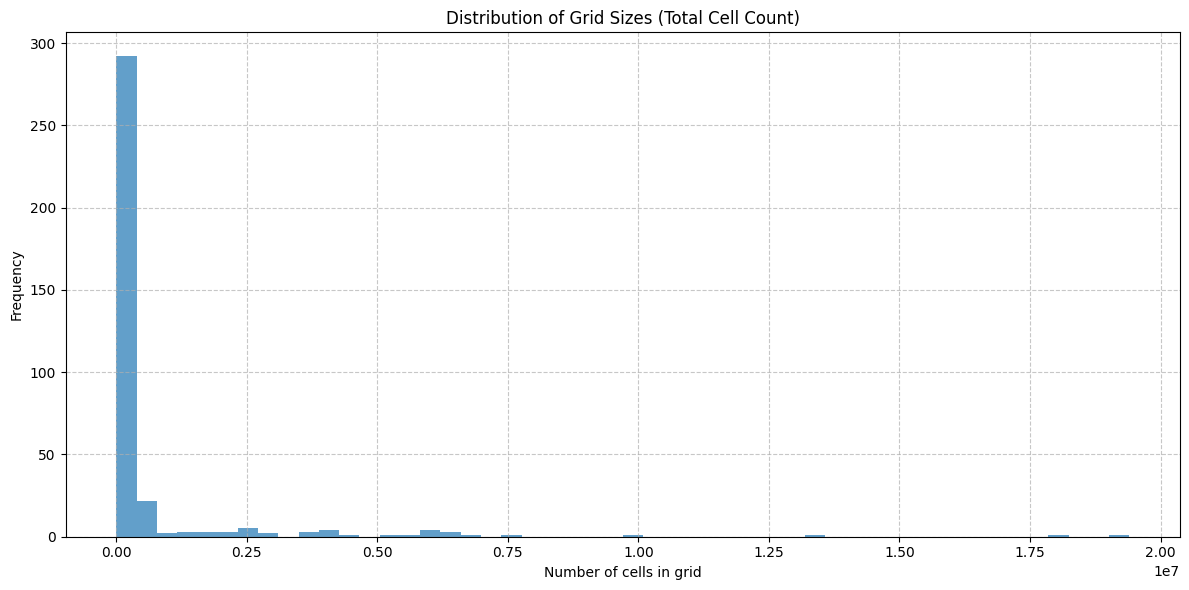

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from collections import Counter

# To store grid shapes 
grid_shapes = []
c=0

for i in src['filename'].unique():
    # Step 1: Load data from CSV
    # Extract columns. Here 'ES' corresponds to the X-axis and 'NS' to the Y-axis.
    es = src[src['filename']==i]['X==EW'].values * input[input['filename']==i]['Dx'].values[0]/5
    ns = src[src['filename']==i]['Y==NS'].values * input[input['filename']==i]['Dx'].values[0]/5
    slip = src[src['filename']==i]['SLIP'].values/src[src['filename']==i]['SLIP'].max()
    # c+=1
    # print(c)

    # Step 2: Recenter coordinates so that (0,0) is the center.
    # We subtract the mean so that the data is centered.
    es_centered = es - np.mean(es)
    ns_centered = ns - np.mean(ns)

    # Step 3: Define a grid of integer-valued pixel positions.
    # Compute grid bounds using the floor/ceil to cover the whole data range.
    x_min = int(np.floor(np.min(es_centered)))
    x_max = int(np.ceil(np.max(es_centered)))
    y_min = int(np.floor(np.min(ns_centered)))
    y_max = int(np.ceil(np.max(ns_centered)))

    # Create a meshgrid with integer positions.
    grid_x, grid_y = np.meshgrid(np.arange(x_min, x_max + 1),
                                np.arange(y_min, y_max + 1))
    
    try:
        # Step 4: Interpolate slip values onto the integer grid.
        # Points is an array of the centered (x,y) coordinates.
        points = np.column_stack((es_centered, ns_centered))
        grid_slip = griddata(points, slip, (grid_x, grid_y), method='nearest', fill_value=0)
        
        # Store the shape of grid_slip
        grid_shapes.append(grid_slip.shape)
        
    except Exception as e:
        print(f"Error with {i}: {e}")
        continue

# Convert shapes to strings for better visualization
grid_shape_strs = [f"{shape[0]}x{shape[1]}" for shape in grid_shapes]

# Count occurrences of each shape
shape_counts = Counter(grid_shape_strs)

# Sort by frequency
sorted_shapes = sorted(shape_counts.items(), key=lambda x: x[1], reverse=True)

# Plot the distribution of grid shapes
plt.figure(figsize=(12, 8))
bars = plt.bar([item[0] for item in sorted_shapes[:20]], [item[1] for item in sorted_shapes[:20]])

# Add count labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height}', ha='center', va='bottom', rotation=0)

plt.title('Distribution of Grid Shapes (Top 20)')
plt.xlabel('Grid Shape (height x width)')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Summary statistics
print(f"Total unique shapes: {len(shape_counts)}")
print(f"Most common shape: {sorted_shapes[0][0]} (Count: {sorted_shapes[0][1]})")

# Find the shape with max width, height and total cells
grid_sizes = [shape[0] * shape[1] for shape in grid_shapes]
max_height = max(shape[0] for shape in grid_shapes)
max_width = max(shape[1] for shape in grid_shapes)
max_size = max(grid_sizes)
max_size_shape = grid_shapes[grid_sizes.index(max_size)]

# print(f"Largest grid dimensions: {max_height}x{max_width}")
print(f"Shape with most cells: {max_size_shape[0]}x{max_size_shape[1]} (Total: {max_size} cells)")
print(f"Average grid size: {sum(grid_sizes)/len(grid_sizes):.1f} cells")

# Plot the distribution of grid sizes (total number of cells)
grid_sizes = [shape[0] * shape[1] for shape in grid_shapes]

plt.figure(figsize=(12, 6))
plt.hist(grid_sizes, bins=50, alpha=0.7)
plt.title('Distribution of Grid Sizes (Total Cell Count)')
plt.xlabel('Number of cells in grid')
plt.ylabel('Frequency')
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()


In [29]:
# Find the shape with max width, height and total cells
grid_sizes = [shape[0] * shape[1] for shape in grid_shapes]
max_height = max(shape[0] for shape in grid_shapes)
max_width = max(shape[1] for shape in grid_shapes)
max_size = max(grid_sizes)
max_size_shape = grid_shapes[grid_sizes.index(max_size)]

print(f"Largest grid dimensions: {max_height}x{max_width}")
print(f"Shape with most cells: {max_size_shape[0]}x{max_size_shape[1]} (Total: {max_size} cells)")
print(f"Average grid size: {sum(grid_sizes)/len(grid_sizes):.1f} cells")


Largest grid dimensions: 5729x5297
Shape with most cells: 3663x5297 (Total: 19402911 cells)
Average grid size: 620181.2 cells


In [21]:
input.columns

Index(['filename', 'Event', 'EventTAG', 'LAT', 'LON', 'DEP', 'LEN_f', 'WID',
       'Mw', 'Mo', 'STRK', 'DIP', 'RAKE', 'Htop', 'HypX', 'HypZ', 'avTr',
       'avVr', 'Nx', 'Nz', 'Fmin', 'Fmax', 'Dx', 'Dz', 'Ntw', 'Nsg', 'LEN_inv',
       'SHF', 'SVF', 'SGM-Data', 'TELE-Data', 'TRIL-Data', 'LEVEL-Data',
       'GPS-Data', 'INSAR-Data', 'SURF-Data', 'OTHER-Data', 'SGM-PHImx',
       'TELE-PHImx', 'TRIL-PHImx', 'LEVEL-PHImx', 'GPS-PHImx', 'INSAR-PHImx',
       'SURF-PHImx', 'OTHER-PHImx', 'SGM-Rmin', 'TELE-Rmin', 'TRIL-Rmin',
       'LEVEL-Rmin', 'GPS-Rmin', 'INSAR-Rmin', 'SURF-Rmin', 'OTHER-Rmin',
       'BBR-Data', 'HR-GPS-Data', 'Hr-GPS-Data', 'InSAR-Data', 'Other-Data',
       'SAT-Data', 'SPOT-Data', 'hr-GPS-Data', 'inSAR-Data', 'level-Data',
       'tril-Data'],
      dtype='object')

In [4]:
max_slip=src['SLIP'].max()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
c=0
cnt=0
for i in src['filename'].unique():

    Dx = input[input['filename']==i]['Dx'].values[0]
    src_df=src[src['filename']==i]
    # Extract and scale coordinates
    es = src_df['X==EW'].values * Dx / 5.0
    ns = src_df['Y==NS'].values * Dx / 5.0
    slip = src_df['SLIP'].values / src_df['SLIP'].max()

    # Recenter coordinates
    es_centered = es - np.mean(es)
    ns_centered = ns - np.mean(ns)

    # Step 3: Define a grid of integer-valued pixel positions.
    # Compute grid bounds using the floor/ceil to cover the whole data range.
    x_min = int(np.floor(np.min(es_centered)))
    x_max = int(np.ceil(np.max(es_centered)))
    y_min = int(np.floor(np.min(ns_centered)))
    y_max = int(np.ceil(np.max(ns_centered)))

    # Create a meshgrid with integer positions.
    grid_x, grid_y = np.meshgrid(np.arange(x_min, x_max + 1),
                                np.arange(y_min, y_max + 1))
    
    try:
        # Step 4: Interpolate slip values onto the integer grid.
        # Points is an array of the centered (x,y) coordinates.
        points = np.column_stack((es_centered, ns_centered))
        grid_slip = griddata(points, slip, (grid_x, grid_y), method='cubic', fill_value=0)

    except:
        print(i)
        continue


    # Optionally, you can replace NaNs (outside the convex hull of your data)
    # # For example, with zeros or using nearest neighbor interpolation:
    # grid_slip = np.where(np.isnan(grid_slip),
    #                      griddata(points, slip, (grid_x, grid_y), method='nearest'),
    #                      grid_slip)

    # plt.figure(figsize=(8, 6))
    # scatter = plt.scatter(es_centered, ns_centered, c=slip, 
    #                     cmap='viridis', s=50, alpha=0.8)
    # plt.colorbar(scatter, label='Normalized Slip')
    # plt.title("Slip Values (Scatter Plot)")
    # plt.xlabel("ES (centered)")
    # plt.ylabel("NS (centered)")
    # plt.grid(True, linestyle='--', alpha=0.7)
    # plt.show()


    # # Step 5: Visualize the image.
    # plt.figure(figsize=(8, 6))
    # plt.imshow(grid_slip, extent=(x_min, x_max, y_min, y_max),
    #         origin='lower', cmap='viridis')
    # plt.colorbar(label='Slip Intensity')
    # plt.title(f"Interpolated Slip Image (Integer Pixel Grid) for {i}")
    # plt.xlabel("ES (centered)")
    # plt.ylabel("NS (centered)")
    # plt.show()

    

    if(grid_slip.shape[0]>=50 or grid_slip.shape[1]>=50):
        print(i)
        cnt+=1
        plt.imsave(F"./Dataset/ALL_IMAGES_LAT_LON/interpolated_slip_image_{i}.png", grid_slip, cmap='viridis',
            vmin=np.nanmin(grid_slip), vmax=np.nanmax(grid_slip))
    
    # break

# GLOBAL EARTHQUAKE DISTRIBUTION

In [ ]:
!pip install cartopy

Map has been saved as 'publication_earthquake_map.png' and 'publication_earthquake_map.pdf'


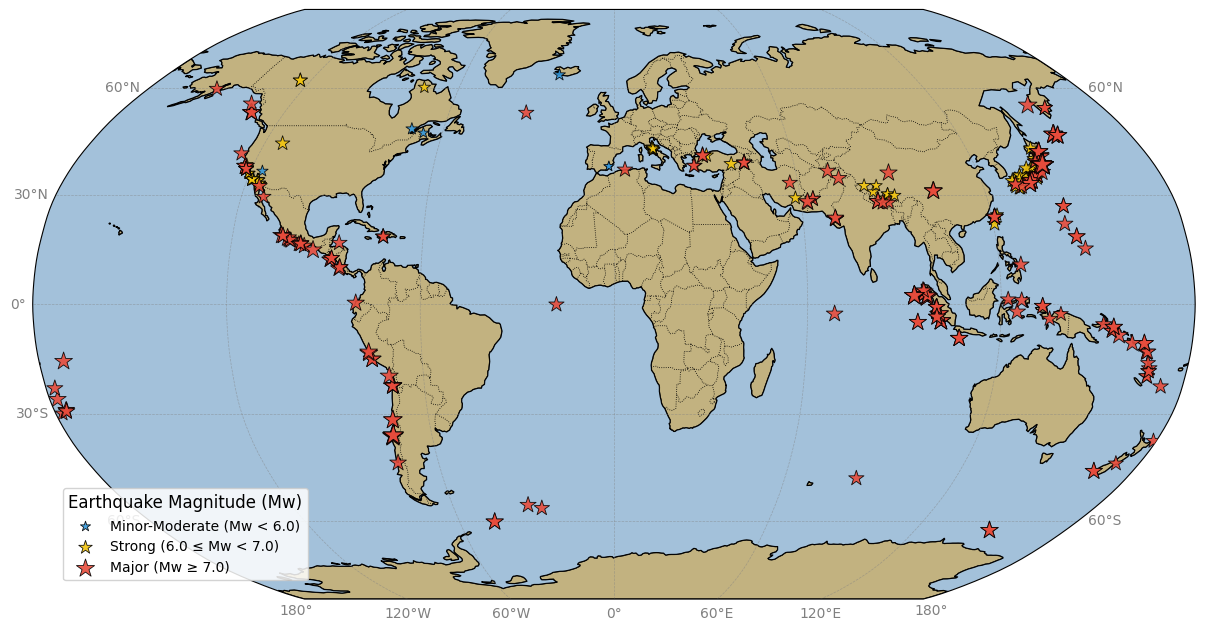

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- 1. Load and Prepare Data ---
try:
    df = pd.read_csv(r'./Dataset/extracted_dataset/non-multisegment/non-multisegment_input.csv')
except FileNotFoundError:
    print("Error: The specified CSV file was not found.")
    exit()

# --- 2. Categorize Earthquake Magnitudes ---
bins = [0, 5.9, 6.9, float('inf')]
labels = ['Minor-Moderate (Mw < 6.0)', 'Strong (6.0 ≤ Mw < 7.0)', 'Major (Mw ≥ 7.0)']
df['Mw_category'] = pd.cut(df['Mw'], bins=bins, labels=labels, right=False)

# --- 3. Define Aesthetics ---
color_map = {
    'Minor-Moderate (Mw < 6.0)': '#3498db',  # Blue
    'Strong (6.0 ≤ Mw < 7.0)': '#f1c40f',    # Yellow
    'Major (Mw ≥ 7.0)': '#e74c3c'            # Red
}

# --- 4. Create Map ---
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax.set_global()

# --- 5. Add Earth-like Map Features ---
# Earthy colors: greenish-brown land, blue ocean
ax.add_feature(cfeature.LAND, zorder=0, edgecolor='black', facecolor='#c2b280')  # Earthy tan-green
ax.add_feature(cfeature.OCEAN, zorder=0, facecolor='#a3c1da')                     # Soft blue
ax.add_feature(cfeature.COASTLINE, zorder=1, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, zorder=1, linestyle=':', linewidth=0.6)

# Add subtle gridlines
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10, 'color': 'gray'}
gl.ylabel_style = {'size': 10, 'color': 'gray'}

# --- 6. Plot Earthquake Data as Stars ---
legend_elements = []
for category in labels:
    subset = df[df['Mw_category'] == category]
    scatter = ax.scatter(subset['LON'], subset['LAT'],
                         s=subset['Mw']**2.5,       # marker size scales with magnitude
                         c=color_map[category],
                         label=category,
                         alpha=0.9,
                         marker='*',                # star marker
                         edgecolors='black',
                         linewidth=0.6,
                         transform=ccrs.PlateCarree(),
                         zorder=10)
    legend_elements.append(scatter)

# --- 7. Add Legend ---
legend = ax.legend(handles=legend_elements,
                   title='Earthquake Magnitude (Mw)',
                   loc='lower left',
                   bbox_to_anchor=(0.02, 0.02),
                   frameon=True,
                   fontsize=10,
                   title_fontsize=12)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.85)

# --- 8. Save Map ---
plt.savefig('publication_earthquake_map.png', dpi=300, bbox_inches='tight', pad_inches=0.2)
plt.savefig('publication_earthquake_map.pdf', bbox_inches='tight', pad_inches=0.2)

print("Map has been saved as 'publication_earthquake_map.png' and 'publication_earthquake_map.pdf'")

plt.show()
